In [17]:
import numpy as np
from matplotlib import pyplot as plt

## Bisection Method

Suppose we want to find a root of a function $f(x)$:

In [18]:
f = lambda x: x**2 - 2*x - 3   # We define our polynomial using using Python's lambda-functions. 

# Read this if you're unfamiliar with lambda-functions:

# https://realpython.com/python-lambda/

which looks like this:

Text(0, 0.5, '$f(x)$')

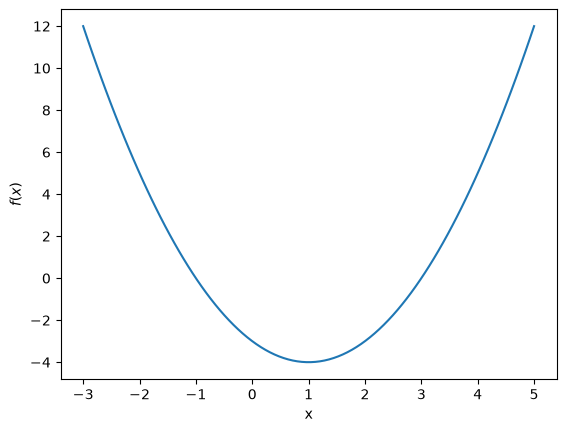

In [19]:
xspan = np.linspace(-3, 5, 100)  # Create a 100 uniformly spaced points between -3 and 5.
plt.plot(xspan, f(xspan))        # Plot the function as plot(x, y)
plt.xlabel("x")                  # Label axes
plt.ylabel(r"$f(x)$")            # That's how you render LaTeX in plots titles and labels: r"$<formula goes here>$"

# Here is a good tutorial if you never used matplotlib before:

# https://matplotlib.org/tutorials/introductory/pyplot.html

Now let's create a function `bisection`, which takes a function `f` and the bounds `a` and `b`, and returns a root of `f` between `a` and `b`. This time we'll take pseudocode from Wikipedia (https://en.wikipedia.org/wiki/Bisection_method).

In [20]:

def bisection(f,                # Function the root of which we're trying to find
              a,                # Left boundary for the root
              b,                # Right boundary for the root
              tol = 1e-8,       # Tolerance 
              nmax = 1000):     # Maximal number of iterations 
    
    if np.sign(f(a))==np.sign(f(b)):
        raise ValueError("sign(f(a)) == sign(f(b)), not valid bracket")
    n = 1
    while n <= nmax:
        c = (a + b) / 2         # Choose a middle point
        if abs(f(c)) < tol:     # If stopping condition is satisfied
            return c            # Return the root
        n = n + 1
        if np.sign(f(c)) == np.sign(f(a)):
            a = c
        else:
            b = c
    print("Method failed")      # Happens only if the method reached nmax iterations without finding a root

From the plot it seems like there are two roots: one is between -2 and 1, and another one is between 1 and 5. Save these two roots into the variables `x0` and `x1` respectively (done for you as an example):

In [21]:

x0 = bisection(f, -2, 1)

x1 = bisection(f, 1, 5)

It's important to check that your values are correct. For instance, we can verify that `f(x0)` and `f(x1)` are close to 0. 

In [22]:
print(f"f(x0) = {f(x0):.5f}. Should be close to 0")
print(f"f(x1) = {f(x1):.5f}. Should be close to 0")

# P.S. if you're unfamiliar Python strings formatting in general or
# with f-strings in particular, here is an instruction:

# http://zetcode.com/python/fstring/

f(x0) = -0.00000. Should be close to 0
f(x1) = 0.00000. Should be close to 0


Since we're using numerical methods, we will almost never get our answers precisely. 

The goal of making these checks is to ensure that the values are reasonable. For instance, if you know that the target value is supposed to be a small positive value, but you got -2123124156.3847594 -- it indicates a mistake in the algorithm and so more debugging is needed.

## NumPy

NumPy is a Python library and a very popular choice when one needs to work with linear algebra objects like matrices and vectors. We will be using numpy throughout the class.

In [23]:
import numpy as np

If you have never used NumPy then I would highly recommend you going through this tutorial first:

https://numpy.org/doc/stable/user/quickstart.html

We also wanted to use this homework to remind you about the importance of dimensions in NumPy. For instance, suppose we have two matrices:

In [24]:
A = np.array([
    [1, 2],
    [3, 4], 
    [5, 6]
])

B = 2*np.eye(3)

If we try to multiply them as-is we will get an error:

In [25]:
A.dot(B)

ValueError: shapes (3,2) and (3,3) not aligned: 2 (dim 1) != 3 (dim 0)

This error tells us that matrix dimensions don't match: the number of columns of A is 2, but the number of rows of B is 3, so the matrices can't be multiplied. 

It gets less obvious when it comes to vectors, mainly because NumPy vectors are one-dimensional objects of shape (N,) which is different from column vectors -- 2-d matrices of shape (N, 1) -- or row-vectors -- 2-d matrices of shape (1, N). This difference may seem natural to people with background in C or Java (1d vs 2d arrays), but might seem counter-intuitive for people with MATLAB background, where all vectors and matrices are 2d by default. 

Here, `u` is a row-vector, so when I try doing an outer product everything goes as a mathematician would expect:

In [ ]:
u = np.array([[1, 2, 3]])
print(f"Shape of u is: {u.shape}")
u.T.dot(u)

Shape of u is: (1, 3)


array([[1, 2, 3],
       [2, 4, 6],
       [3, 6, 9]])

However, `v` is a 1d-array, and so the behavior of .dot() is different: instead of an outer product we get an inner product.

In [ ]:
v = np.array([1, 2, 3])
print(f"Shape of v is: {v.shape}")
v.T.dot(v)

Shape of v is: (3,)


np.int64(14)

I would recommend sticking to 2d matrices (to column vectors and row vectors instead of arrays) whenever you do linear algebra operations.

Please make sure you familiarized yourself with numpy enough to see what we are doing differently in four very similar code snippets below to get four different outcomes. This understanding might save you hours of debugging in future. 

In [ ]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])
u.dot(v)

np.int64(32)

In [ ]:
u = np.array([[1, 2, 3]])
v = np.array([[4, 5, 6]])
u*v

array([[ 4, 10, 18]])

In [ ]:
u = np.array([[1, 2, 3]]).T
v = np.array([[4, 5, 6]])
u.dot(v)

array([[ 4,  5,  6],
       [ 8, 10, 12],
       [12, 15, 18]])

In [ ]:
u = np.array([[1, 2, 3]])
v = np.array([[4, 5, 6]])
u.dot(v)

ValueError: shapes (1,3) and (1,3) not aligned: 3 (dim 1) != 1 (dim 0)

As a basic NumPy proficiency test on translating math expression to NumPy syntax, calculate the following expression: 

$C = \log\det(B^Tvv^TB + B^TB \odot B^TB)$

Where $B = (1, 2; 3, 4; 5, 6)$, $v$ is a vector of ones, and $\odot$ is an element-wise product (called the Hadamard product). Use NumPy functions for the logarithm (`np.log`) and determinant (`np.linalg.det`) 

In [ ]:
v = np.ones((3,1))

B = np.array([[1,2],[3,4],[5,6]])

##===GRADED===##
C = np.log(np.linalg.det(B.T.dot(v).dot(v.T).dot(B) + (B.T.dot(B))*(B.T.dot(B))))
C

np.float64(11.568776357710231)

## Forward Euler Method

Many homeworks in this class will ask you to solve ordinary differential equations (ODEs) numerically. The simplest method for an initial value problem

$$\dot{u} = f(t, u), \qquad u(t_0) = u_0$$

is the forward Euler method. With a constant step size $h$ it approximates $u(t_n)$, where $t_n = t_0 + nh$, by

$$U_{n+1} = U_n + h\, f(t_n, U_n), \qquad U_0 = u_0.$$

Implement the function `forward_euler_solver`. It takes the right-hand side function `f(t, u)`, the initial time `t0`, the initial condition `u0`, the step size `h` and the number of steps `N`, and returns the entire solution trajectory $U_0, U_1, \dots, U_N$ as a NumPy array of length `N+1`.

Your solver should work for an arbitrary right-hand side `f`, so do not hard-code the ODE from the next task inside it. Since we will apply it to an ODE with complex-valued solutions, store the trajectory in an array with `dtype=complex`.

In [ ]:

def forward_euler_solver(f,     # Right-hand side function f(t, u) of the ODE du/dt = f(t, u)
                         t0,    # Initial time
                         u0,    # Initial condition u(t0)
                         h,     # Step size
                         N):    # Number of steps

    U = np.array([0] * (N + 1), dtype = complex)           # Allocate the trajectory array of length N+1 (use dtype=complex)
    U[0] = u0
    for n in range(N):
        U[n+1] = U[n] + h * f(t0 + n * h, U[n])            # One forward Euler step
    return U

Now apply your solver to the ODE

$$\dot{u} = \lambda u, \qquad u(0) = 1,$$

with the complex number $\lambda = -0.8 + 0.2i$ (in Python the imaginary unit is written as `j`, so this is `-0.8 + 0.2j`). Use step size $h = 0.1$ and $N = 50$ steps, i.e. integrate up to $t = 5$.

1. Define the right-hand side `rhs` as a lambda-function of `(t, u)`.
2. Save the forward Euler trajectory into the variable `U_euler`.
3. The exact solution of this ODE is $u(t) = u_0 e^{\lambda (t - t_0)}$. Evaluate it on the time grid `t` and save it into `u_exact`.
4. Save the absolute error at the final time, $|U_N - u(t_N)|$, into the variable `err`.

In [30]:
lam = -0.8 + 0.2j   # Complex parameter lambda
t0 = 0              # Initial time
u0 = 1              # Initial condition
h = 0.1             # Step size
N = 50              # Number of steps

t = t0 + h * np.arange(N + 1)   # Time grid t_0, t_1, ..., t_N

rhs = lambda t, u: lam * u             # Right-hand side of the ODE as a lambda-function of (t, u)

U_euler = forward_euler_solver(rhs, t0, u0, h, N)       # Forward Euler trajectory

u_exact = np.exp(lam * t)       # Exact solution evaluated on the time grid t

err = np.abs(U_euler[50] - u_exact[50])           # Absolute error |U_N - u(t_N)| at the final time

As before, let's check that the result is reasonable by comparing the real and imaginary parts of the numerical and exact solutions:

Error at the final time: 0.00304


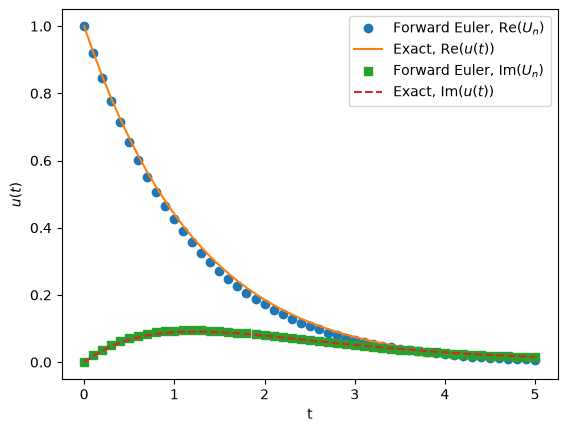

In [28]:
plt.plot(t, U_euler.real, "o", label=r"Forward Euler, Re$(U_n)$")
plt.plot(t, u_exact.real, "-", label=r"Exact, Re$(u(t))$")
plt.plot(t, U_euler.imag, "s", label=r"Forward Euler, Im$(U_n)$")
plt.plot(t, u_exact.imag, "--", label=r"Exact, Im$(u(t))$")
plt.xlabel("t")
plt.ylabel(r"$u(t)$")
plt.legend()

print(f"Error at the final time: {err:.5f}")

## Submitting your work to Gradescope

You need to submit this Jupyter Notebook to Gradescope. There is no limit for the number of attempts this time. 


Gradescope will give you 0 points if your any of your code cells fail, so **please don't forget to delete all my code cells which produce errors**. Those were for illustration purposes.